# 05 Customer Churn Analysis

This notebook improves the churn model by using a more realistic, leakage-aware design.

The original academic-style churn model reached perfect accuracy, but perfect accuracy is suspicious because the model used features that were too close to the churn definition. This version predicts whether a customer will stop purchasing in the **next 90 days**, using only information available before a cutoff date.


## Model Choice

For this type of project, I would not use an LSTM. LSTMs are useful for sequence-heavy problems such as text, sensor streams, or detailed event sequences. This dataset is mainly tabular transaction data, so tree-based models are more suitable.

In industry, XGBoost or LightGBM would be strong options for tabular churn. For this portfolio version, I use `RandomForestClassifier` because it is available in scikit-learn, easy to explain, handles non-linear patterns, and performed well under time-based validation. I also compare it against a simple Gradient Boosting model and a dummy baseline.


## Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

sns.set_style('whitegrid')


## Load Cleaned Data

The notebook uses the cleaned local dataset created in notebook 01. If it is not available, it falls back to the public sample file.


In [2]:
cleaned_path = '../data/processed/cleaned_luminatech_transactions.csv'
sample_path = '../data/sample/sample_luminatech_data.csv'

if os.path.exists(cleaned_path):
    Dataset_cleaned = pd.read_csv(cleaned_path, dtype={'customer_code': str}, low_memory=False)
else:
    Dataset_cleaned = pd.read_csv(sample_path, dtype={'customer_code': str})

Dataset_cleaned['invoice_date'] = pd.to_datetime(Dataset_cleaned['invoice_date'], errors='coerce')
Dataset_cleaned['order_date'] = pd.to_datetime(Dataset_cleaned['order_date'], errors='coerce')

if 'profit' not in Dataset_cleaned.columns:
    Dataset_cleaned['profit'] = Dataset_cleaned['value_sales'] - Dataset_cleaned['value_cost']

if 'time_gap' not in Dataset_cleaned.columns:
    Dataset_cleaned['time_gap'] = (Dataset_cleaned['invoice_date'] - Dataset_cleaned['order_date']).dt.days

Dataset_cleaned['profit_margin'] = (Dataset_cleaned['value_sales'] - Dataset_cleaned['value_cost']) / Dataset_cleaned['value_sales']
Dataset_cleaned['profit_margin'] = Dataset_cleaned['profit_margin'].replace([np.inf, -np.inf], np.nan)

print('Rows:', len(Dataset_cleaned))
print('Customers:', Dataset_cleaned['customer_code'].nunique())
print('Date range:', Dataset_cleaned['invoice_date'].min(), 'to', Dataset_cleaned['invoice_date'].max())
Dataset_cleaned.head()


Rows: 1966082
Customers: 4478
Date range: 2012-01-02 00:00:00 to 2013-12-31 00:00:00


,accounting_date,fiscal_year,fiscal_month,calendar_year,calendar_month,calendar_day,company_code,customer_code,customer_district_code,item_code,...,currency,invoice_number,line_number,invoice_date,customer_order_number,order_date,dss_update_time,profit,time_gap,profit_margin
0,2012-05-09,2012,11,2012,5,9,101,411800601,410,GENIE8WWWBC,...,AUD,2217887,1,2012-05-09,2865354,2012-05-09,49:58.7,40.2024,0,0.184077
1,2012-02-16,2012,8,2012,2,16,101,361000403,300,GENIE8WWWBC,...,AUD,2185745,1,2012-02-16,2833515,2012-02-16,49:58.7,12.8232,0,0.334984
2,2012-05-09,2012,11,2012,5,9,101,361000403,300,GENIE8WWWBC,...,AUD,2217807,1,2012-05-09,2864857,2012-05-08,49:58.7,14.7432,1,0.366746
3,2012-05-18,2012,11,2012,5,18,101,565540415,500,GENIE8WWWBC,...,AUD,2222758,1,2012-05-18,2869759,2012-05-18,49:58.7,7.3716,0,0.366746
4,2012-01-09,2012,7,2012,1,9,101,565540415,500,GENIE8WWWBC,...,AUD,2170374,1,2012-01-09,2819189,2012-01-09,49:58.7,6.4116,0,0.334984


**Result explanation:** this confirms the model is using the full cleaned local dataset and shows the customer base and date coverage available for churn modelling.


## Why the Original Churn Accuracy Was Suspicious

The earlier churn model defined churn using the most recent purchase date and also used `recency` as a model feature calculated from the same end date. That gives the model information that is almost the answer itself.

The fix is to create a prediction date, build features only from transactions before that date, and then check whether the customer purchases in the future window.


## Create Time-Based Churn Snapshots

Each snapshot works like a business scoring date:

- Use purchase history up to the cutoff date.
- Predict whether the customer makes no purchase in the next 90 days.
- Train on earlier cutoffs.
- Test on the later cutoff.

This is more realistic than a random split because the model is tested on a later business period.


In [3]:
def make_churn_snapshot(data, cutoff_date, prediction_days=90):
    cutoff_date = pd.to_datetime(cutoff_date)
    prediction_end_date = cutoff_date + pd.Timedelta(days=prediction_days)

    history = data[data['invoice_date'] <= cutoff_date].copy()
    future = data[
        (data['invoice_date'] > cutoff_date) &
        (data['invoice_date'] <= prediction_end_date)
    ].copy()

    customer_features = history.groupby('customer_code').agg(
        last_purchase_date=('invoice_date', 'max'),
        first_purchase_date=('invoice_date', 'min'),
        total_spent=('value_sales', 'sum'),
        total_profit=('profit', 'sum'),
        order_count=('invoice_date', 'count'),
        avg_order_value=('value_sales', 'mean'),
        total_quantity=('value_quantity', 'sum'),
        avg_quantity=('value_quantity', 'mean'),
        profit_margin=('profit_margin', 'mean'),
        avg_time_gap=('time_gap', 'mean'),
        customer_district_code=('customer_district_code', 'first')
    ).reset_index()

    customer_features['snapshot_date'] = cutoff_date
    customer_features['recency_days'] = (cutoff_date - customer_features['last_purchase_date']).dt.days
    customer_features['tenure_days'] = (cutoff_date - customer_features['first_purchase_date']).dt.days
    customer_features['active_months'] = (customer_features['tenure_days'] / 30).clip(lower=1)
    customer_features['order_frequency_per_month'] = customer_features['order_count'] / customer_features['active_months']

    future_customers = set(future['customer_code'].unique())
    customer_features['churned_next_90_days'] = ~customer_features['customer_code'].isin(future_customers)
    customer_features['churned_next_90_days'] = customer_features['churned_next_90_days'].astype(int)

    return customer_features


In [4]:
cutoff_dates = ['2013-03-31', '2013-06-30', '2013-09-30']

snapshot_list = []
for cutoff in cutoff_dates:
    snapshot = make_churn_snapshot(Dataset_cleaned, cutoff, prediction_days=90)
    snapshot_list.append(snapshot)

churn_snapshots = pd.concat(snapshot_list, ignore_index=True)

snapshot_summary = churn_snapshots.groupby('snapshot_date')['churned_next_90_days'].agg(['count', 'mean'])
snapshot_summary['churn_rate_percent'] = snapshot_summary['mean'] * 100
snapshot_summary


,count,mean,churn_rate_percent
snapshot_date,,,
2013-03-31,4024,0.246024,24.602386
2013-06-30,4181,0.266922,26.692179
2013-09-30,4350,0.319310,31.931034


**Result explanation:** the churn rate changes by cutoff date. The final test period is the September 2013 snapshot, where churn means no purchase in the next 90 days.


## Train-Test Split by Time

This is the most important improvement. The model trains on March and June 2013 snapshots, then tests on September 2013. This simulates using historical data to score customers at a future point in time.


In [5]:
feature_columns = [
    'customer_district_code',
    'total_spent',
    'total_profit',
    'order_count',
    'avg_order_value',
    'total_quantity',
    'avg_quantity',
    'profit_margin',
    'avg_time_gap',
    'recency_days',
    'tenure_days',
    'order_frequency_per_month'
]

model_data = churn_snapshots[feature_columns + ['snapshot_date', 'churned_next_90_days']].copy()
model_data = model_data.replace([np.inf, -np.inf], np.nan).fillna(0)

train_data = model_data[model_data['snapshot_date'] < pd.to_datetime('2013-09-30')]
test_data = model_data[model_data['snapshot_date'] == pd.to_datetime('2013-09-30')]

X_train = train_data[feature_columns]
y_train = train_data['churned_next_90_days']

X_test = test_data[feature_columns]
y_test = test_data['churned_next_90_days']

print('Training rows:', len(X_train))
print('Testing rows:', len(X_test))
print('Test churn rate:', round(y_test.mean() * 100, 2), '%')


Training rows: 8205
Testing rows: 4350
Test churn rate: 31.93 %


**Result explanation:** this split is more industry-relevant because the test data comes from a later time period, not from a random sample mixed with training history.


## Compare Baseline and Tree-Based Models

The dummy model shows what happens if we always predict the majority class. The real model must beat this baseline and also identify actual churners, not just achieve high accuracy.


In [6]:
models = {
    'Dummy baseline': DummyClassifier(strategy='most_frequent'),
    'Random Forest': RandomForestClassifier(
        n_estimators=120,
        max_depth=8,
        min_samples_leaf=20,
        class_weight='balanced',
        random_state=42,
        n_jobs=1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        random_state=42,
        max_depth=3,
        n_estimators=150,
        learning_rate=0.05
    )
}

model_results = []
fitted_models = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[model_name] = model

    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    model_results.append({
        'model': model_name,
        'accuracy': accuracy_score(y_test, predictions),
        'precision': precision_score(y_test, predictions, zero_division=0),
        'recall': recall_score(y_test, predictions, zero_division=0),
        'f1_score': f1_score(y_test, predictions, zero_division=0),
        'roc_auc': roc_auc_score(y_test, probabilities)
    })

results_df = pd.DataFrame(model_results)
results_df


,model,accuracy,precision,recall,f1_score,roc_auc
0,Dummy baseline,0.680690,0.000000,0.000000,0.000000,0.500000
1,Random Forest,0.885057,0.777639,0.896328,0.832776,0.953208
2,Gradient Boosting,0.878391,0.863176,0.735781,0.794403,0.951905


**Result explanation:** the dummy model can look acceptable on accuracy because most customers do not churn in the test period, but it fails to identify churners. The Random Forest is preferred because it gives the best balance for retention action, especially recall and F1-score.


## Visualise Model Comparison


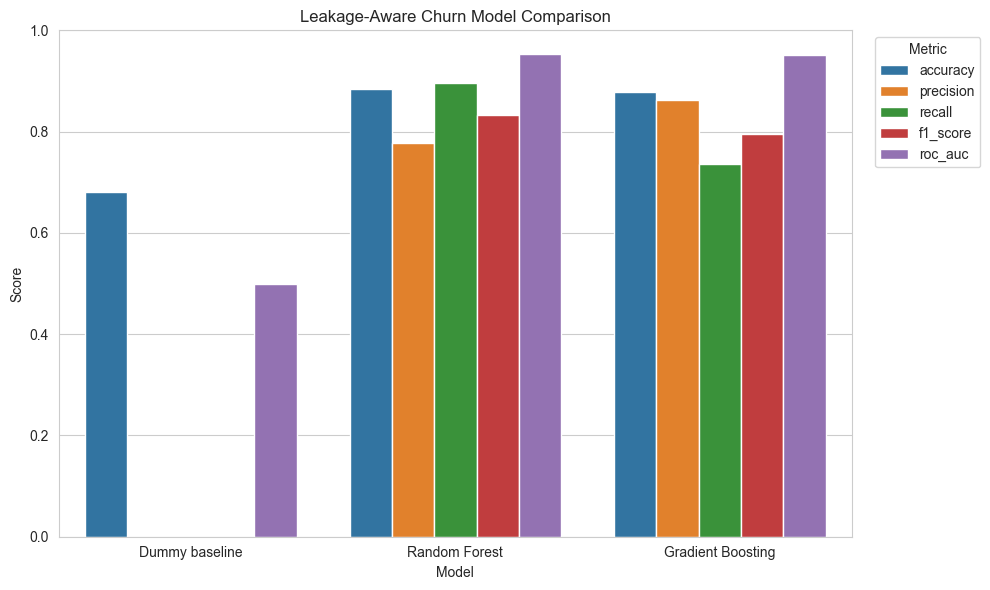

In [7]:
plt.figure(figsize=(10, 6))
plot_data = results_df.melt(id_vars='model', value_vars=['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc'])
sns.barplot(data=plot_data, x='model', y='value', hue='variable')
plt.title('Leakage-Aware Churn Model Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../visuals/10_churn_model_comparison.png', dpi=160)
plt.show()


## Final Model: Random Forest

The Random Forest is selected as the final model because it captures non-linear customer behaviour, performs well on a later time period, and remains easier to explain than deep learning.


In [8]:
final_model = fitted_models['Random Forest']
final_predictions = final_model.predict(X_test)
final_probabilities = final_model.predict_proba(X_test)[:, 1]

print('Classification Report:')
print(classification_report(y_test, final_predictions))

conf_matrix = confusion_matrix(y_test, final_predictions)
conf_matrix


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.88      0.91      2961
           1       0.78      0.90      0.83      1389

    accuracy                           0.89      4350
   macro avg       0.86      0.89      0.87      4350
weighted avg       0.89      0.89      0.89      4350



array([[2605,  356],
       [ 144, 1245]])

**Result explanation:** recall is especially important for churn because the business wants to catch customers who are likely to leave. False positives are not ideal, but they are often less costly than missing high-risk customers completely.


## Confusion Matrix


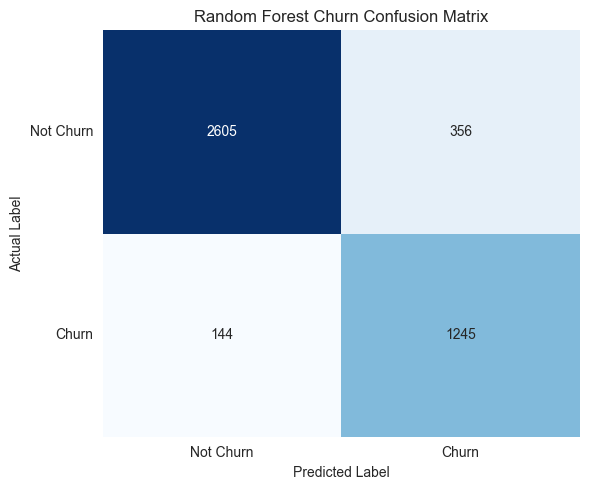

In [9]:
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Random Forest Churn Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.xticks([0.5, 1.5], ['Not Churn', 'Churn'])
plt.yticks([0.5, 1.5], ['Not Churn', 'Churn'], rotation=0)
plt.tight_layout()
plt.savefig('../visuals/11_churn_confusion_matrix.png', dpi=160)
plt.show()


## Feature Importance


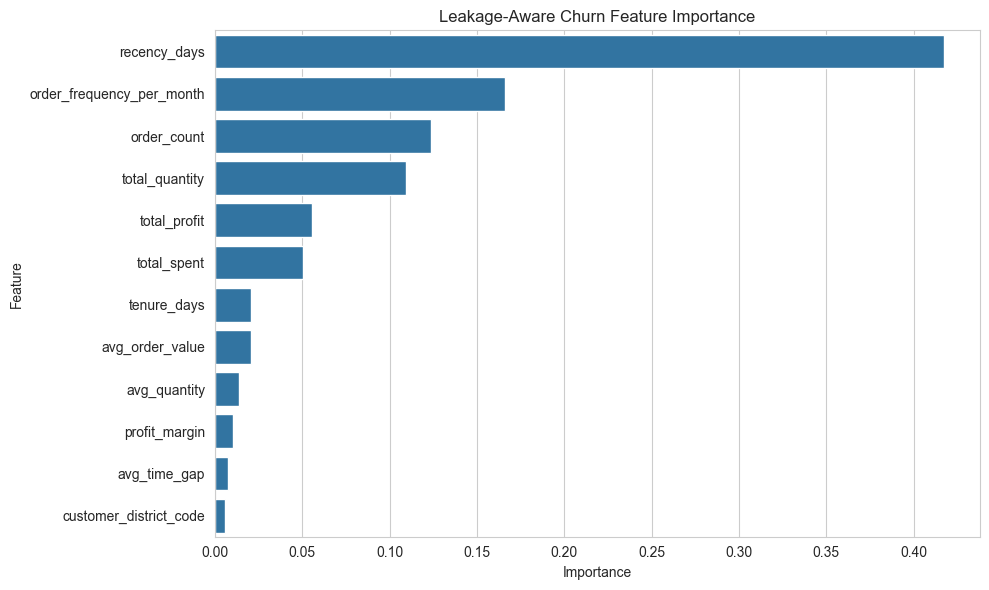

,Feature,Importance
9,recency_days,0.417118
11,order_frequency_per_month,0.165843
3,order_count,0.123876
5,total_quantity,0.109141
2,total_profit,0.055342
1,total_spent,0.050602
10,tenure_days,0.020728
4,avg_order_value,0.020574
6,avg_quantity,0.013635
7,profit_margin,0.010169


In [10]:
feature_importances = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': final_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances)
plt.title('Leakage-Aware Churn Feature Importance')
plt.tight_layout()
plt.savefig('../visuals/09_churn_feature_importance.png', dpi=160)
plt.show()

feature_importances


**Result explanation:** recency remains important, but now it is calculated only as of the scoring date. That makes it a valid business feature rather than direct leakage from the final dataset end date. Order frequency and order count also matter because they capture customer engagement.


## Create Customer Risk Scores

A useful industry output is not only a model score, but a customer list that sales or account teams could act on.


In [11]:
test_customers = churn_snapshots[churn_snapshots['snapshot_date'] == pd.to_datetime('2013-09-30')].copy()
test_customers['churn_probability'] = final_probabilities

def risk_band(probability):
    if probability >= 0.70:
        return 'High risk'
    elif probability >= 0.40:
        return 'Medium risk'
    else:
        return 'Low risk'

test_customers['risk_band'] = test_customers['churn_probability'].apply(risk_band)

risk_summary = test_customers.groupby('risk_band').agg(
    customers=('customer_code', 'count'),
    actual_churn_rate=('churned_next_90_days', 'mean'),
    average_churn_probability=('churn_probability', 'mean'),
    total_spent=('total_spent', 'sum')
).reset_index()

risk_summary['actual_churn_rate'] = risk_summary['actual_churn_rate'] * 100
risk_summary['average_churn_probability'] = risk_summary['average_churn_probability'] * 100
risk_summary


,risk_band,customers,actual_churn_rate,average_churn_probability,total_spent
0,High risk,1228,86.644951,87.637695,1.836670e+07
1,Low risk,2620,4.122137,7.244725,6.850021e+08
2,Medium risk,502,43.227092,55.942973,1.734468e+07


**Result explanation:** risk bands turn the model into a business action list. High-risk customers can be prioritised for retention campaigns, while medium-risk customers can be monitored or targeted with lower-cost engagement.


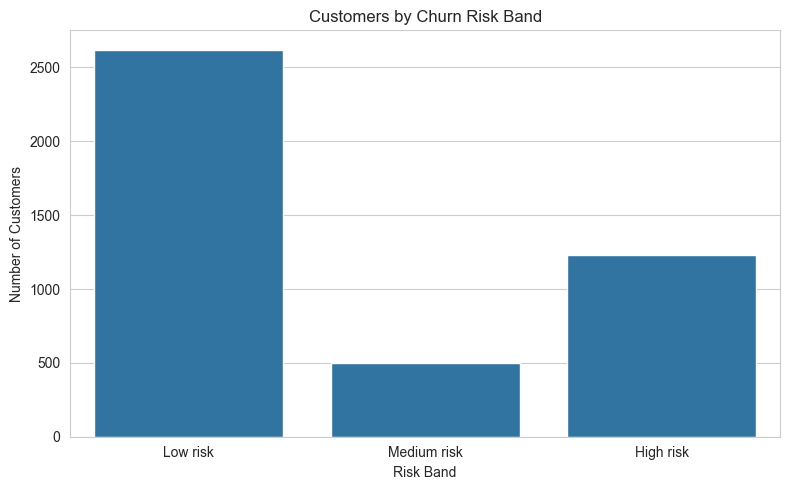

In [12]:
plt.figure(figsize=(8, 5))
sns.barplot(data=risk_summary, x='risk_band', y='customers', order=['Low risk', 'Medium risk', 'High risk'])
plt.title('Customers by Churn Risk Band')
plt.xlabel('Risk Band')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('../visuals/12_churn_risk_segments.png', dpi=160)
plt.show()


## Final Interpretation

The improved churn model is more realistic than the original perfect-accuracy model. It does not use future data to create features, it tests on a later time period, and it compares performance against a dummy baseline.

The result is not ?perfect,? which is actually a good sign. It means the model is closer to a real business prediction problem. The model should still be improved with more time periods, external customer context, probability calibration, and business cost-based threshold tuning before production use.
